In [1]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
import matplotlib.pyplot as plt
from Modeling.models.ROM import ROM
%matplotlib widget

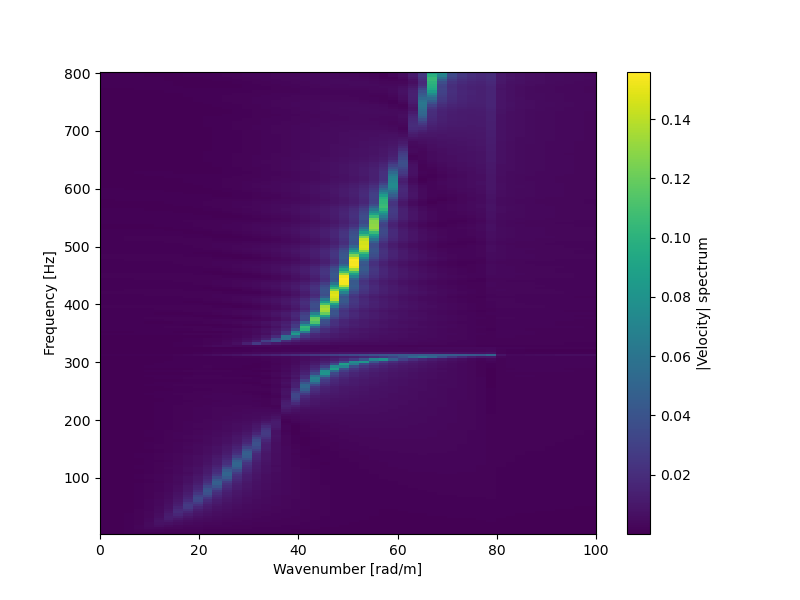

In [2]:
import matplotlib.pyplot as plt
Q = 300
params = PiezoBeamParams( 
    Q = Q, L_b=3.185
    )
rom = ROM(params, N=80)

# ki1 = 1000 + 1000 * (np.arange(rom.S//2) % 2)
# ki2 = 2000 - 1000 * (np.arange(rom.S//2) % 2)
x_eval = np.linspace(0, rom.p.L_b, 1000)
# K_i = np.concatenate([ki1, ki2])
K_i = 50
# w = np.concatenate([np.linspace(40, 50, 100), np.linspace(60, 70, 100)])*2*np.pi
w = np.linspace(5, 800, 200)*2*np.pi
result = rom.dispersion_analysis(
j_exc=299, R_c=1e3, K_c=0, K_p=1e-4, K_i=K_i,
w=w, x_eval=x_eval
)
wavenumber = result['wavenumber']
freq = result['freq']
spectrum = result['spectrum']
velocity_field = result['veloc'] # shape (npts, nfreq)
plt.figure(figsize=(8,6))
plt.pcolormesh( wavenumber, freq, np.abs(spectrum), shading='auto')

plt.ylabel('Frequency [Hz]')
plt.xlabel('Wavenumber [rad/m]')
plt.xlim([0, 100])
plt.colorbar(label='|Velocity| spectrum')
 
# for i in range(0, len(freq),10):
#     plt.figure(figsize=(8,6))  
#     plt.plot(x_eval, velocity_field[:, i], label=f'Frequency = {freq[i]:.1f} Hz')
#     plt.legend()
#     plt.show()

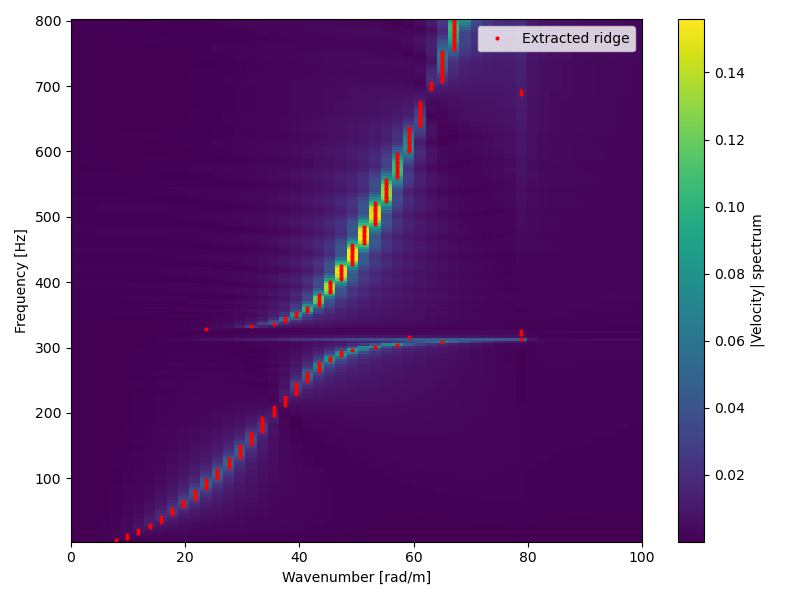

In [4]:

import numpy as np
import matplotlib.pyplot as plt

# dominant k index for each frequency
k_idx = np.argmax(np.abs(spectrum), axis=1)

# ridge
k_ridge = wavenumber[k_idx]
omega_ridge = 2 * np.pi * freq
plt.figure(figsize=(8,6))

# background spectrum
plt.pcolormesh(
	wavenumber,
	freq,
	np.abs(spectrum),
	shading='auto',
	cmap='viridis'
)

# ridge overlay
plt.plot(
	k_ridge,
	freq,
	'r.',
	ms=4,
	label='Extracted ridge'
)

plt.xlabel('Wavenumber [rad/m]')
plt.ylabel('Frequency [Hz]')
plt.xlim([0, 100])
plt.colorbar(label='|Velocity| spectrum')
plt.legend()
plt.tight_layout()
plt.show()


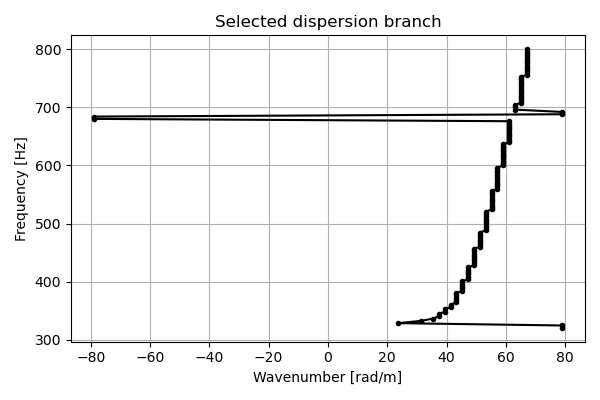

In [10]:
fmin = 320   # Hz
fmax = 800   # Hz

mask = (freq >= fmin) & (freq <= fmax) 

k_b = k_ridge[mask]
f_b = freq[mask]
omega_b = 2 * np.pi * f_b

plt.figure(figsize=(6,4))
plt.plot(k_b, f_b, 'k.-')
plt.xlabel('Wavenumber [rad/m]')
plt.ylabel('Frequency [Hz]')
plt.title('Selected dispersion branch')
plt.grid(True)
plt.tight_layout()
plt.show()


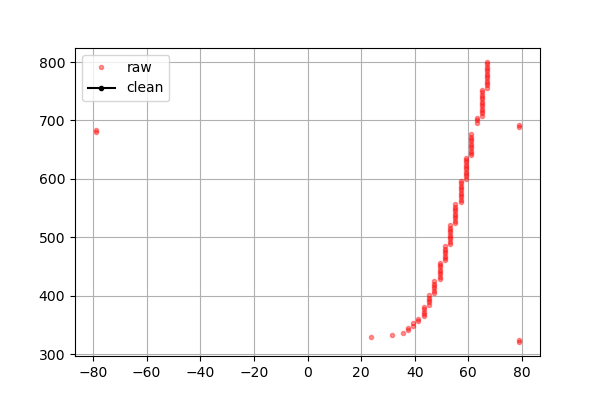

In [12]:
# sort by frequency (important)
idx = np.argsort(f_b)
f_sorted = f_b[idx]
k_sorted = k_b[idx]

# numerical derivative dk/df
dk_df = np.gradient(k_sorted, f_sorted)

# robust threshold using MAD
med = np.median(dk_df)
mad = np.median(np.abs(dk_df - med))

threshold = 5 * mad   # adjust (3–6 typical)

mask_clean = np.abs(dk_df - med) < threshold

k_clean = k_sorted[mask_clean]
f_clean = f_sorted[mask_clean]
from scipy.signal import medfilt

window = 7   # odd number
k_med = medfilt(k_sorted, kernel_size=window)

diff = np.abs(k_sorted - k_med)
mad = np.median(diff)

mask_clean = diff < 4 * mad

k_clean = k_sorted[mask_clean]
f_clean = f_sorted[mask_clean]

plt.figure(figsize=(6,4))
plt.plot(k_b, f_b, 'r.', alpha=0.4, label='raw')
plt.plot(k_clean, f_clean, 'k.-', label='clean')
plt.legend()
plt.grid(True)
plt.show()


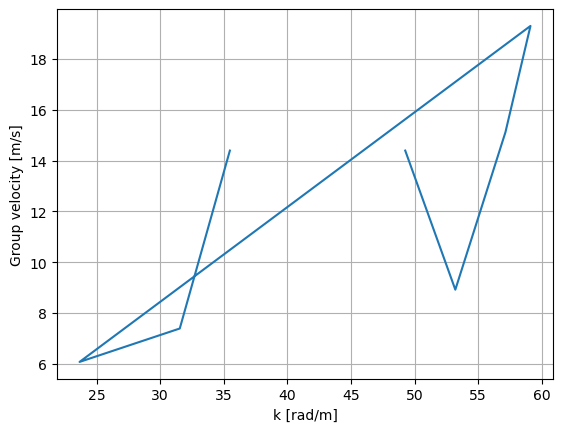

In [ ]:
from scipy.signal import savgol_filter

omega_s = savgol_filter(omega_b, 21, 3)

c_g = np.gradient(omega_s, k_b)
plt.figure()
plt.plot(k_b, c_g)
plt.xlabel('k [rad/m]')
plt.ylabel('Group velocity [m/s]')
plt.grid(True)
plt.show()
